### Import all the libraries and the dataset 

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/covid19-data-from-john-hopkins-university/CONVENIENT_global_deaths.csv
/kaggle/input/covid19-data-from-john-hopkins-university/RAW_global_deaths.csv
/kaggle/input/covid19-data-from-john-hopkins-university/RAW_global_confirmed_cases.csv
/kaggle/input/covid19-data-from-john-hopkins-university/CONVENIENT_us_deaths.csv
/kaggle/input/covid19-data-from-john-hopkins-university/CONVENIENT_global_metadata.csv
/kaggle/input/covid19-data-from-john-hopkins-university/RAW_us_confirmed_cases.csv
/kaggle/input/covid19-data-from-john-hopkins-university/CONVENIENT_us_confirmed_cases.csv
/kaggle/input/covid19-data-from-john-hopkins-university/CONVENIENT_global_confirmed_cases.csv
/kaggle/input/covid19-data-from-john-hopkins-university/CONVENIENT_us_metadata.csv
/kaggle/input/covid19-data-from-john-hopkins-university/RAW_us_deaths.csv
/kaggle/input/world-happiness-report-2021/world-happiness-report-2021.csv
/kaggle/input/world-happiness-report-2021/world-happiness-report.csv


In [5]:
corona_dataset = pd.read_csv('../input/covid19-data-from-john-hopkins-university/RAW_global_confirmed_cases.csv')

In [6]:
corona_dataset.head()

,Country/Region,Province/State,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,Afghanistan,NaN,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,Albania,NaN,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,Algeria,NaN,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,Andorra,NaN,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,Angola,NaN,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


In [7]:
corona_dataset.shape

(289, 1147)

In [8]:
corona_dataset.drop(['Lat', 'Long', 'Province/State'], axis = 1, inplace=True)

In [9]:
corona_dataset_aggregated = corona_dataset.groupby('Country/Region').sum()

In [10]:
corona_dataset_aggregated.head()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
Albania,0,0,0,0,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
Algeria,0,0,0,0,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
Andorra,0,0,0,0,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
Angola,0,0,0,0,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


In [11]:
corona_dataset_aggregated.shape

(201, 1143)

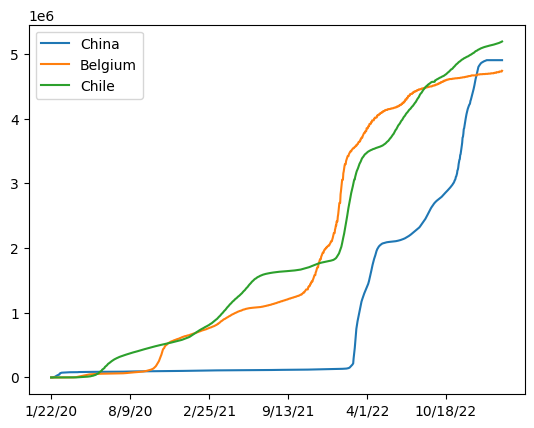

In [12]:
corona_dataset_aggregated.loc["China"].plot()
corona_dataset_aggregated.loc["Belgium"].plot()
corona_dataset_aggregated.loc["Chile"].plot()
plt.legend()

<Axes: >

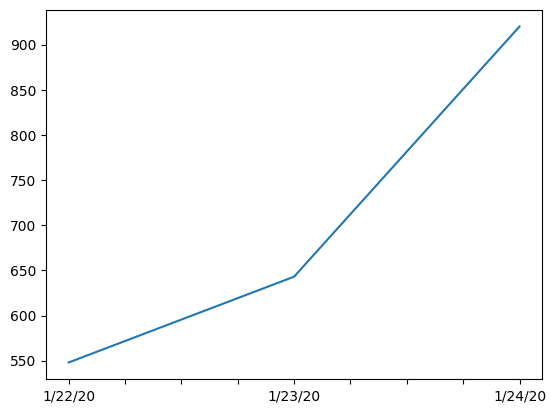

In [13]:
corona_dataset_aggregated.loc["China"][:3].plot()

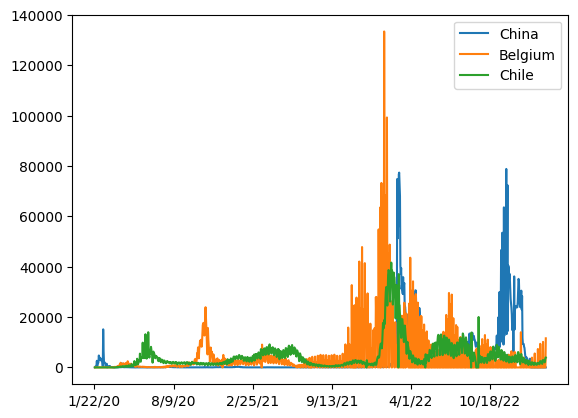

In [14]:
corona_dataset_aggregated.loc["China"].diff().plot()
corona_dataset_aggregated.loc["Belgium"].diff().plot()
corona_dataset_aggregated.loc["Chile"].diff().plot()
plt.legend()

In [15]:
countries = list(corona_dataset_aggregated.index)
max_infection_rates = []
for c in countries :
    max_infection_rates.append(corona_dataset_aggregated.loc[c].diff().max())
corona_dataset_aggregated["Max infection rate"] = max_infection_rates

In [16]:
corona_data = pd.DataFrame(corona_dataset_aggregated["Max infection rate"])

In [17]:
corona_data.head()

,Max infection rate
Country/Region,
Afghanistan,3243.0
Albania,4789.0
Algeria,2521.0
Andorra,2313.0
Angola,5035.0


In [18]:
corona_data.shape

(201, 1)

In [19]:
happiness_report = pd.read_csv('../input/world-happiness-report-2021/world-happiness-report-2021.csv')

In [20]:
happiness_report.head()

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798


In [21]:
happiness_report.shape

(149, 20)

In [22]:
happiness_data = happiness_report[["Country name", "Logged GDP per capita", "Social support", "Healthy life expectancy", "Freedom to make life choices"]]
happiness_data.set_index("Country name", inplace = True)

In [23]:
happiness_data.head()

,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
Country name,,,,
Finland,10.775,0.954,72.0,0.949
Denmark,10.933,0.954,72.7,0.946
Switzerland,11.117,0.942,74.4,0.919
Iceland,10.878,0.983,73.0,0.955
Netherlands,10.932,0.942,72.4,0.913


In [24]:
data = corona_data.join(happiness_data, how = 'inner')

In [25]:
data.head()

,Max infection rate,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
Afghanistan,3243.0,7.695,0.463,52.493,0.382
Albania,4789.0,9.520,0.697,68.999,0.785
Algeria,2521.0,9.342,0.802,66.005,0.480
Argentina,139853.0,9.962,0.898,69.000,0.828
Armenia,4388.0,9.487,0.799,67.055,0.825


In [26]:
data.shape

(138, 5)

In [27]:
corr_matrix = data.corr()

In [28]:
corr_matrix

,Max infection rate,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices
Max infection rate,1.000000,0.322941,0.236806,0.344605,0.052039
Logged GDP per capita,0.322941,1.000000,0.798452,0.872090,0.456510
Social support,0.236806,0.798452,1.000000,0.748850,0.486266
Healthy life expectancy,0.344605,0.872090,0.748850,1.000000,0.493911
Freedom to make life choices,0.052039,0.456510,0.486266,0.493911,1.000000


<Axes: >

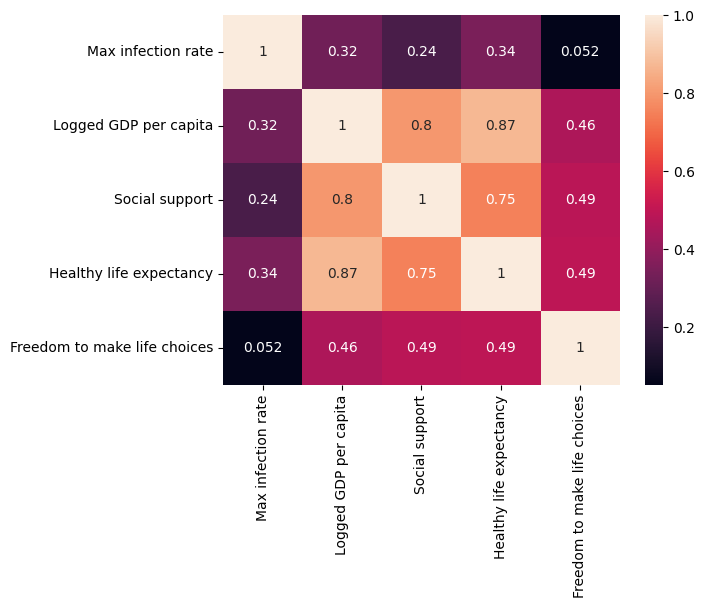

In [29]:
sns.heatmap(corr_matrix, annot=True)

<Axes: xlabel='Freedom to make life choices', ylabel='Max infection rate'>

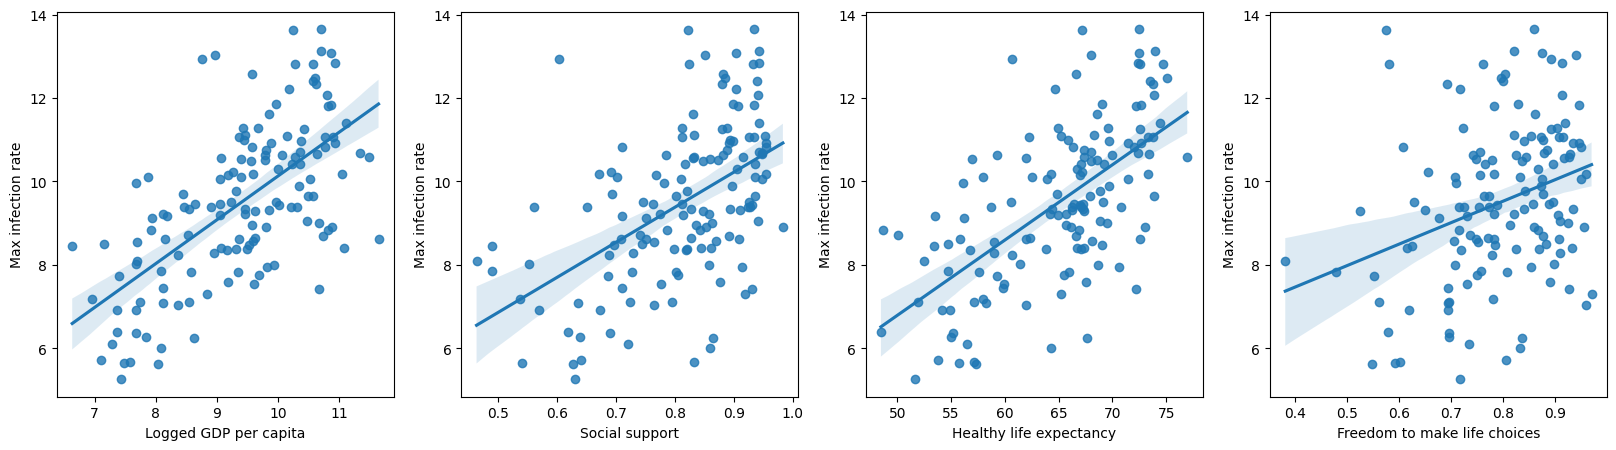

In [30]:
fig, axs = plt.subplots(ncols=4, figsize=(20, 5))
oy = np.log(data["Max infection rate"])
sns.regplot(x = data['Logged GDP per capita'], y = oy , ax=axs[0])
sns.regplot(x = data['Social support'], y = oy , ax=axs[1])
sns.regplot(x = data['Healthy life expectancy'], y = oy , ax=axs[2])
sns.regplot(x = data['Freedom to make life choices'], y = oy , ax=axs[3])